In [1]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
from arch import arch_model

torch.manual_seed(1)
np.random.seed(1)
device = "cuda" if torch.cuda.is_available() else "cpu"


In [2]:
data = pd.read_csv("IBM.csv")
data["Date"] = pd.to_datetime(data["Date"])
data = data.sort_values("Date").reset_index(drop=True)

returns = 100 * np.log(data["Close_IBM"]).diff().dropna().to_numpy().astype("float32")
dates = data.loc[data["Close_IBM"].shift(1).notna(), "Date"].reset_index(drop=True)

forecast_horizon = 30
context_length = 30
train = returns[:-forecast_horizon]
test = returns[-forecast_horizon:]
test_dates = dates.iloc[-forecast_horizon:]
realized_volatility = pd.Series(returns).rolling(forecast_horizon).std().to_numpy()
test_realized_volatility = realized_volatility[-forecast_horizon:]


In [3]:
garch_fit = arch_model(
    train,
    mean="Constant",
    vol="GARCH",
    p=1,
    q=1,
    dist="t",
    rescale=False,
).fit(disp="off")

garch_forecast = garch_fit.forecast(
    horizon=forecast_horizon,
    reindex=False,
)

garch_variance = garch_forecast.variance.iloc[-1].to_numpy()
garch_volatility = np.sqrt(garch_variance)
garch_30_day_volatility = np.sqrt(np.mean(garch_variance))


In [4]:
def make_windows(values, context):
    x, y = [], []
    for i in range(len(values) - context):
        x.append(values[i:i + context])
        y.append(values[i + context])
    return torch.tensor(np.asarray(x)), torch.tensor(np.asarray(y))

transformer_x, transformer_y = make_windows(train, context_length)
transformer_loader = DataLoader(
    TensorDataset(transformer_x.float(), transformer_y.float()),
    batch_size=64,
    shuffle=True,
)


In [5]:
class PositionalEncoding(nn.Module):
    def __init__(self, dimension, length):
        super().__init__()
        position = torch.arange(length).unsqueeze(1)
        frequency = torch.exp(torch.arange(0, dimension, 2) * (-math.log(10000.0) / dimension))
        encoding = torch.zeros(length, dimension)
        encoding[:, 0::2] = torch.sin(position * frequency)
        encoding[:, 1::2] = torch.cos(position * frequency)
        self.register_buffer("encoding", encoding.unsqueeze(0))

    def forward(self, x):
        return x + self.encoding[:, :x.shape[1]]

class TransformerVolatilityModel(nn.Module):
    def __init__(self, context, dimension=16, heads=2, layers=1, degrees_of_freedom=5.0):
        super().__init__()
        self.context = context
        self.degrees_of_freedom = degrees_of_freedom
        self.input = nn.Linear(1, dimension)
        self.position = PositionalEncoding(dimension, context)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=dimension,
            nhead=heads,
            dim_feedforward=2 * dimension,
            dropout=0.0,
            batch_first=True,
            norm_first=True,
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, layers)
        self.norm = nn.LayerNorm(dimension)
        self.output = nn.Linear(dimension, 2)

    def forward(self, x, target=None):
        x = self.position(self.input(x.unsqueeze(-1)))
        x = self.norm(self.encoder(x)[:, -1])
        parameters = self.output(x)
        mean = parameters[:, 0]
        scale = torch.nn.functional.softplus(parameters[:, 1]) + 1e-4
        distribution = torch.distributions.StudentT(self.degrees_of_freedom, mean, scale)
        loss = None if target is None else -distribution.log_prob(target).mean()
        return distribution, loss

    @torch.no_grad()
    def forecast(self, context, horizon):
        self.eval()
        values = list(context.astype("float32"))
        means, scales = [], []
        for _ in range(horizon):
            x = torch.tensor(values[-self.context:], dtype=torch.float32, device=device).unsqueeze(0)
            distribution, _ = self(x)
            means.append(distribution.mean.item())
            scales.append(distribution.scale.item())
            values.append(distribution.sample().item())
        return np.asarray(means), np.asarray(scales)


In [6]:
transformer_model = TransformerVolatilityModel(context_length).to(device)
optimizer = torch.optim.AdamW(transformer_model.parameters(), lr=1e-3, weight_decay=1e-4)

for epoch in range(40):
    transformer_model.train()
    for x_batch, y_batch in transformer_loader:
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)
        _, loss = transformer_model(x_batch, y_batch)
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(transformer_model.parameters(), 1.0)
        optimizer.step()
    if epoch % 10 == 0:
        print(epoch, float(loss))


C:\Users\trist\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torch\nn\modules\transformer.py:307: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(f"enable_nested_tensor is True, but self.use_nested_tensor is False because {why_not_sparsity_fast_path}")


0 1.9202545881271362
10 1.5796535015106201
20 1.5854260921478271
30 1.889815092086792


GARCH 30-day volatility forecast: 2.901375
Transformer 30-day volatility forecast: 2.157578
GARCH MSE: 1.500481
Transformer MSE: 3.840503


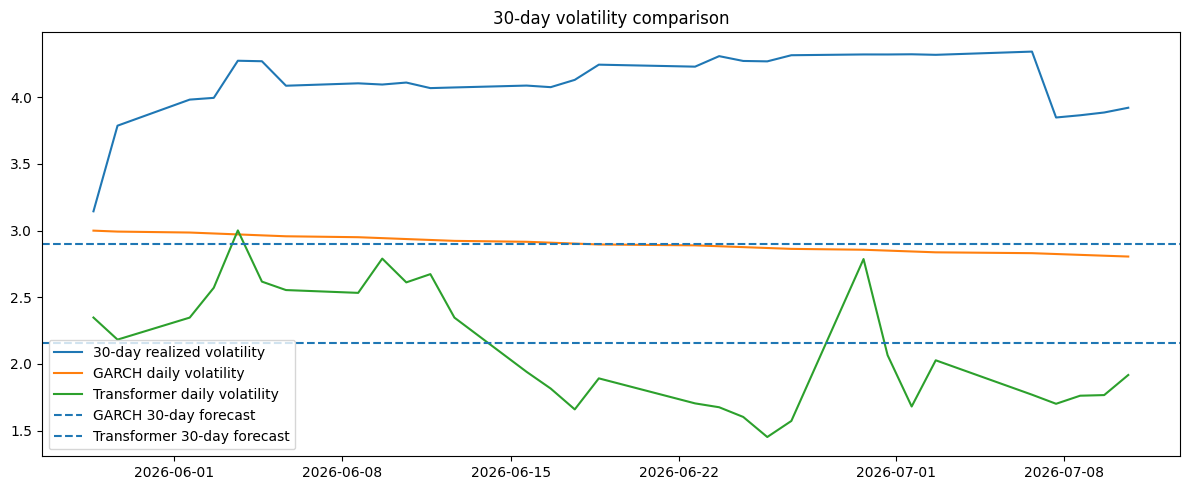

,Date,Actual return,30-day realized volatility,GARCH daily volatility,Transformer daily volatility,GARCH 30-day forecast,Transformer 30-day forecast
0,2026-05-28 16:00:00,3.473454,3.144919,3.000027,2.348365,2.901375,2.157578
1,2026-05-29 16:00:00,11.964003,3.787027,2.992888,2.182796,2.901375,2.157578
2,2026-06-01 16:00:00,7.321052,3.982616,2.985782,2.347948,2.901375,2.157578
3,2026-06-02 16:00:00,2.712396,3.995708,2.978708,2.571766,2.901375,2.157578
4,2026-06-03 16:00:00,-7.438138,4.274016,2.971666,3.001716,2.901375,2.157578
5,2026-06-04 16:00:00,-1.271008,4.270258,2.964656,2.617749,2.901375,2.157578
6,2026-06-05 16:00:00,-5.773752,4.086639,2.957678,2.554410,2.901375,2.157578
7,2026-06-08 16:00:00,-1.421372,4.104674,2.950731,2.533381,2.901375,2.157578
8,2026-06-09 16:00:00,-1.192900,4.095582,2.943817,2.790318,2.901375,2.157578
9,2026-06-10 16:00:00,-1.866018,4.110406,2.936934,2.612040,2.901375,2.157578


In [7]:
transformer_mean, transformer_scale = transformer_model.forecast(
    train[-context_length:],
    forecast_horizon,
)

transformer_volatility = transformer_scale * np.sqrt(5.0 / 3.0)
transformer_30_day_volatility = np.sqrt(np.mean(transformer_volatility ** 2))

comparison = pd.DataFrame({
    "Date": test_dates.to_numpy(),
    "Actual return": test,
    "30-day realized volatility": test_realized_volatility,
    "GARCH daily volatility": garch_volatility,
    "Transformer daily volatility": transformer_volatility,
})

comparison["GARCH 30-day forecast"] = garch_30_day_volatility
comparison["Transformer 30-day forecast"] = transformer_30_day_volatility

garch_mse = np.mean((garch_30_day_volatility - test_realized_volatility) ** 2)
transformer_mse = np.mean((transformer_30_day_volatility - test_realized_volatility) ** 2)

print(f"GARCH 30-day volatility forecast: {garch_30_day_volatility:.6f}")
print(f"Transformer 30-day volatility forecast: {transformer_30_day_volatility:.6f}")
print(f"GARCH MSE: {garch_mse:.6f}")
print(f"Transformer MSE: {transformer_mse:.6f}")

plt.figure(figsize=(12, 5))
plt.plot(test_dates, test_realized_volatility, label="30-day realized volatility")
plt.plot(test_dates, garch_volatility, label="GARCH daily volatility")
plt.plot(test_dates, transformer_volatility, label="Transformer daily volatility")
plt.axhline(garch_30_day_volatility, linestyle="--", label="GARCH 30-day forecast")
plt.axhline(transformer_30_day_volatility, linestyle="--", label="Transformer 30-day forecast")
plt.legend()
plt.title("30-day volatility comparison")
plt.tight_layout()
plt.show()

comparison
